# 03: The First Surprise

Reference pilot notebook: a deterministic eight-bit rule can produce visually irregular structure, and a one-cell perturbation can acquire a measurable future footprint.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
def elementary_step(state: np.ndarray, rule: int) -> np.ndarray:
    left = np.roll(state, 1)
    centre = state
    right = np.roll(state, -1)
    neighborhood = (left << 2) | (centre << 1) | right
    return ((rule >> neighborhood) & 1).astype(np.uint8)


def single_seed(width: int) -> np.ndarray:
    state = np.zeros(width, dtype=np.uint8)
    state[width // 2] = 1
    return state


def run_rule(rule: int, width: int, generations: int, initial_state=None) -> np.ndarray:
    state = single_seed(width) if initial_state is None else initial_state.astype(np.uint8).copy()
    history = np.zeros((generations, width), dtype=np.uint8)
    history[0] = state
    for t in range(1, generations):
        state = elementary_step(state, rule)
        history[t] = state
    return history


def show_spacetime(history, title, path=None, figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(history, cmap="binary", interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Space")
    ax.set_ylabel("Time")
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    plt.show()


In [3]:
EXPERIMENT = {"hero": {"rule": 30, "width": 301, "generations": 150}, "comparison": {"width": 241, "generations": 110}, "perturbation": {"rule": 30, "width": 301, "generations": 130}, "growth": {"rule": 30, "width": 501, "generations": 180}}
EXPERIMENT


{'hero': {'rule': 30, 'width': 301, 'generations': 150},
 'comparison': {'width': 241, 'generations': 110},
 'perturbation': {'rule': 30, 'width': 301, 'generations': 130},
 'growth': {'rule': 30, 'width': 501, 'generations': 180}}

## Baseline observation: Rule 30


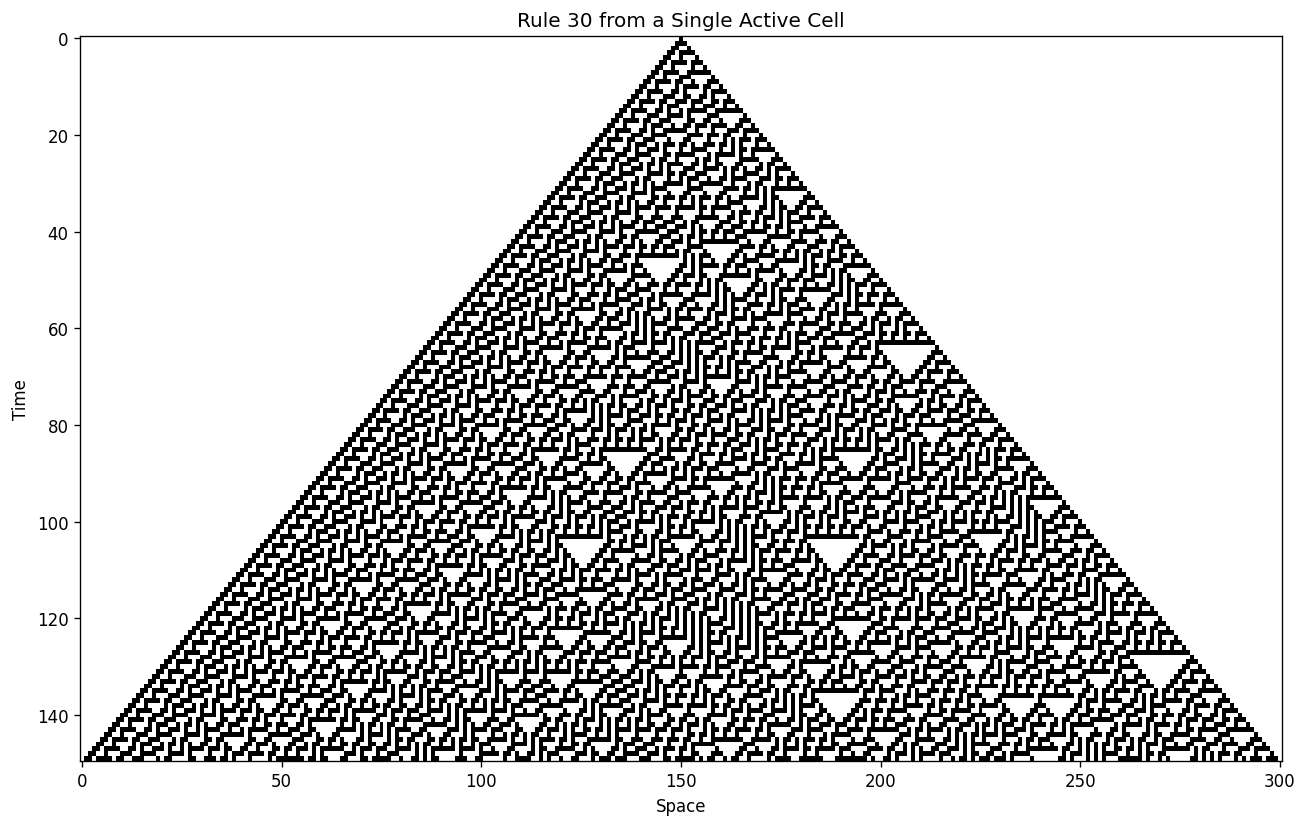

In [4]:
hero = run_rule(**EXPERIMENT["hero"])
show_spacetime(hero, "Rule 30 from a Single Active Cell", FIG_DIR / "ch03-rule30-hero.png", figsize=(11, 7))


## Control: same setup, different local rule


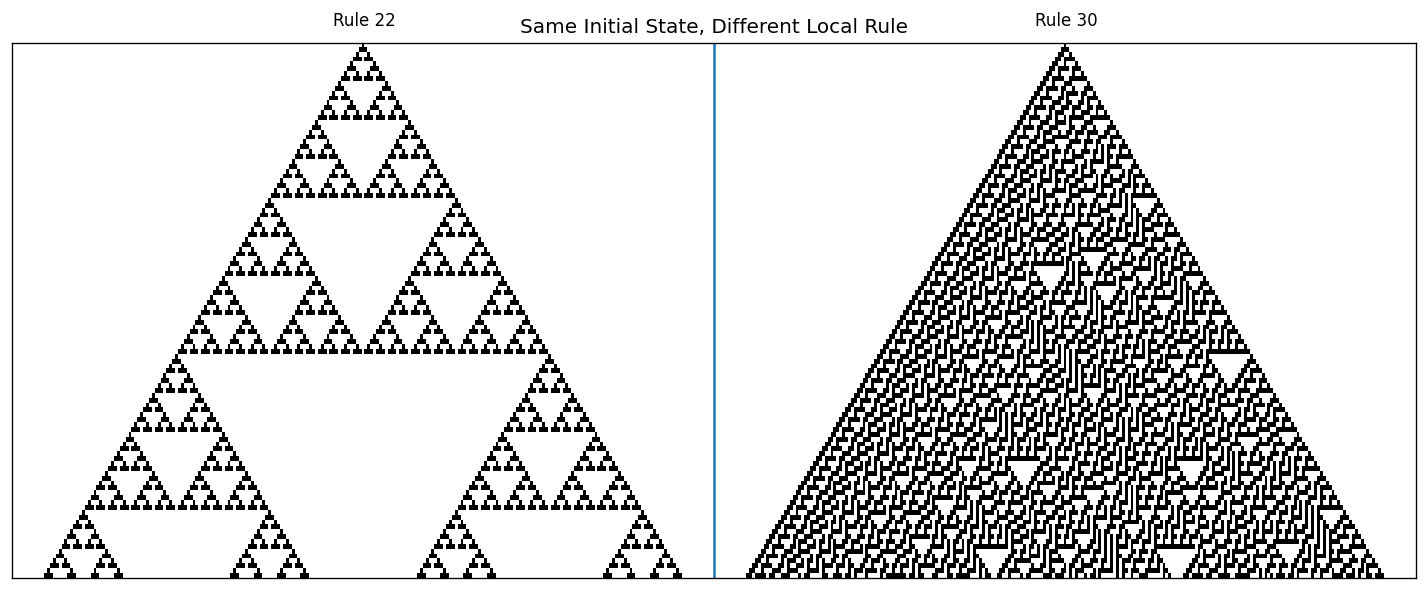

In [5]:
w = EXPERIMENT["comparison"]["width"]; g = EXPERIMENT["comparison"]["generations"]; initial = single_seed(w)
r22 = run_rule(22, w, g, initial); r30 = run_rule(30, w, g, initial)
combined = np.concatenate([r22, r30], axis=1)
fig, ax = plt.subplots(figsize=(12, 5)); ax.imshow(combined, cmap="binary", interpolation="nearest", aspect="auto", vmin=0, vmax=1); ax.axvline(w-.5); ax.text(w*.5, -4, "Rule 22", ha="center"); ax.text(w*1.5, -4, "Rule 30", ha="center"); ax.set(title="Same Initial State, Different Local Rule", yticks=[], xticks=[]); fig.tight_layout(); fig.savefig(FIG_DIR / "ch03-rule22-vs-rule30.png", bbox_inches="tight"); plt.show()


## Intervention: change one bit in the initial world


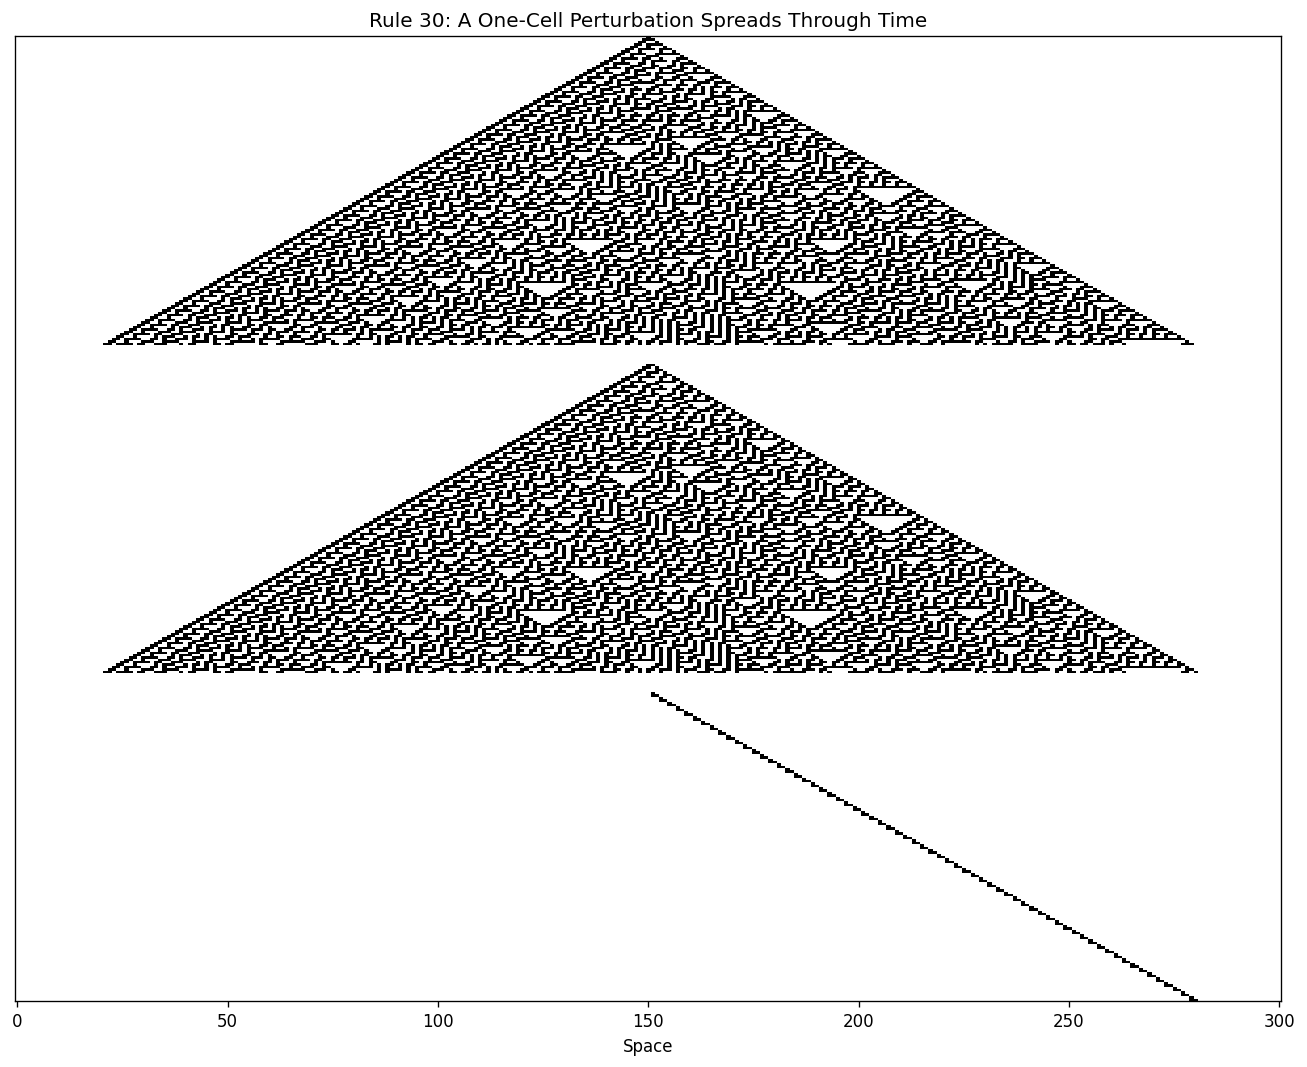

In [6]:
w = EXPERIMENT["perturbation"]["width"]; g = EXPERIMENT["perturbation"]["generations"]
a = single_seed(w); b = single_seed(w); b[w//2 + 1] = 1
ha = run_rule(30, w, g, a); hb = run_rule(30, w, g, b); diff = (ha != hb).astype(np.uint8)
sep = np.zeros((8, w), dtype=np.uint8); stack = np.concatenate([ha, sep, hb, sep, diff])
fig, ax = plt.subplots(figsize=(11, 9)); ax.imshow(stack, cmap="binary", interpolation="nearest", aspect="auto", vmin=0, vmax=1); ax.set(title="Rule 30: A One-Cell Perturbation Spreads Through Time", yticks=[], xlabel="Space"); fig.tight_layout(); fig.savefig(FIG_DIR / "ch03-rule30-perturbation.png", bbox_inches="tight"); plt.show()


## Measurement: Hamming/difference growth


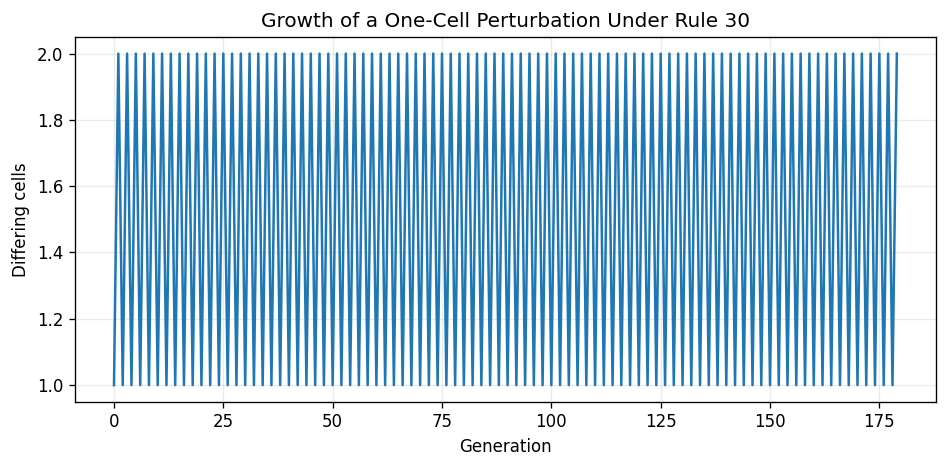

{'initial_difference': 1, 'final_difference': 2, 'max_difference': 2}

In [7]:
w = EXPERIMENT["growth"]["width"]; g = EXPERIMENT["growth"]["generations"]
a = single_seed(w); b = single_seed(w); b[w//2 + 1] = 1
ha = run_rule(30, w, g, a); hb = run_rule(30, w, g, b); differing = (ha != hb).sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4)); ax.plot(np.arange(g), differing); ax.set(title="Growth of a One-Cell Perturbation Under Rule 30", xlabel="Generation", ylabel="Differing cells"); ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(FIG_DIR / "ch03-rule30-difference-growth.png", bbox_inches="tight"); plt.show()
{"initial_difference": int(differing[0]), "final_difference": int(differing[-1]), "max_difference": int(differing.max())}


## What the evidence supports

Rule 30 is deterministic; its spacetime diagram contains irregular regions; a one-cell initial perturbation spreads and can be measured. Sensitivity is not automatically chaos.

## Provenance

**Book chapter**

`content/books/digital-life/03-the-first-surprise/index.md`

**Research scripts used**

- `scripts/books/digital-life/ch03_the_first_surprise.py`

**Book figures reproduced**

- `static/images/books/digital-life/ch03-rule30-hero.png`
- `static/images/books/digital-life/ch03-rule22-vs-rule30.png`
- `static/images/books/digital-life/ch03-rule30-perturbation.png`
- `static/images/books/digital-life/ch03-rule30-difference-growth.png`
